# Notebook 01 - EDA + Baselines

Projeto de previsão de churn em telecomunicações.

## Objetivos deste notebook
- Realizar análise exploratória dos dados
- Fazer limpeza inicial e tratamento de tipos
- Construir pipelines de pré-processamento
- Treinar modelos baseline
- Registrar experimentos no MLflow


## 1. Imports e configuração

In [1]:
# Core
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    precision_recall_curve,
)

#RandomForest
from sklearn.ensemble import RandomForestClassifier

# Tracking
import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


## 2. Carregamento dos dados

O notebook assume que o arquivo está em:

`../data/raw/Telco_customer_churn.xlsx`

Se você estiver executando este notebook a partir da pasta raiz do projeto, troque para `data/raw/Telco_customer_churn.xlsx`.


In [2]:
DATA_PATH = Path("../data/raw/Telco_customer_churn.xlsx")

if not DATA_PATH.exists():
    alt_path = Path("data/raw/Telco_customer_churn.xlsx")
    if alt_path.exists():
        DATA_PATH = alt_path
    else:
        raise FileNotFoundError(
            "Arquivo não encontrado. Verifique se 'Telco_customer_churn.xlsx' está em data/raw/."
        )

df = pd.read_excel(DATA_PATH, engine="openpyxl")
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## 3. Limpeza inicial

In [8]:
# Padronização simples dos nomes das colunas
df.columns = df.columns.str.strip()

# Remoção de colunas irrelevantes ou com forte risco de leakage
cols_to_drop = [
    "CustomerID",
    "Count",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
    "Lat Long",
]

df = df.drop(columns=cols_to_drop, errors="ignore")

df.head()


,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


### 3.1 Definição da variável alvo

In [9]:
target = "Churn Value"
df[target].value_counts()


Churn Value
0    5174
1    1869
Name: count, dtype: int64

### 3.2 Conversão de binárias Yes/No para 1/0

A conversão é aplicada apenas às colunas estritamente binárias com valores `Yes` e `No`.


In [10]:
object_cols = df.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    unique_vals = set(df[col].dropna().unique())
    if unique_vals == {"Yes", "No"}:
        df[col] = df[col].map({"Yes": 1, "No": 0})

df.head()


,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,3239
1,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,0,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,2701
2,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,0,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.5,1,5372
3,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,0,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1,5003
4,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,0,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.3,1,5340


### 3.3 Tratamento de tipos

`Total Charges` frequentemente precisa de coerção para numérico.


In [11]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df.dtypes.sort_values()


CLTV                   int64
Churn Value            int64
Paperless Billing      int64
Phone Service          int64
Tenure Months          int64
Dependents             int64
Senior Citizen         int64
Partner                int64
Zip Code               int64
Longitude            float64
Latitude             float64
Monthly Charges      float64
Total Charges        float64
Streaming Movies      object
Contract              object
Payment Method        object
Streaming TV          object
Country               object
Device Protection     object
Online Backup         object
Online Security       object
Multiple Lines        object
Gender                object
City                  object
State                 object
Tech Support          object
Internet Service      object
dtype: object

### 3.4 Valores ausentes

In [12]:
df.isnull().sum().sort_values(ascending=False)

Total Charges        11
Country               0
Online Security       0
Churn Value           0
Monthly Charges       0
Payment Method        0
Paperless Billing     0
Contract              0
Streaming Movies      0
Streaming TV          0
Tech Support          0
Device Protection     0
Online Backup         0
Internet Service      0
State                 0
Multiple Lines        0
Phone Service         0
Tenure Months         0
Dependents            0
Partner               0
Senior Citizen        0
Gender                0
Longitude             0
Latitude              0
Zip Code              0
City                  0
CLTV                  0
dtype: int64

## 4. EDA - análise exploratória

### 4.1 Distribuição do target

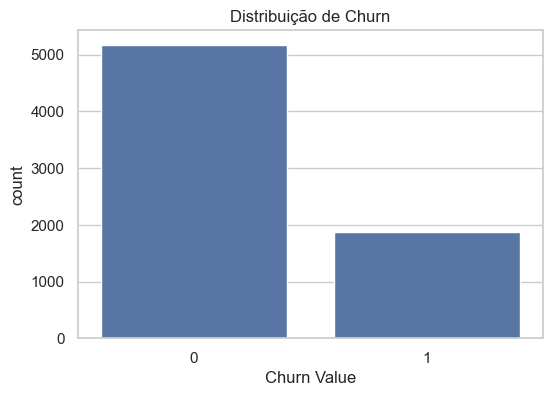

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df)
plt.title("Distribuição de Churn")
plt.show()

print(df[target].value_counts(normalize=True))


### 4.2 Churn por tipo de contrato

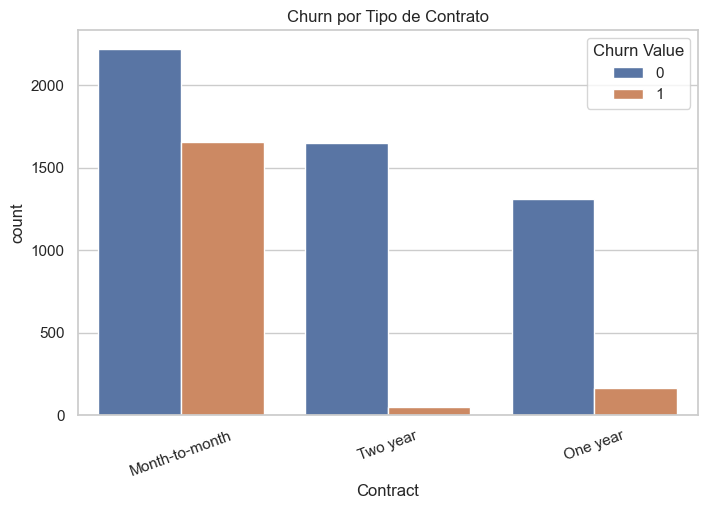

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Contract", hue=target, data=df)
plt.title("Churn por Tipo de Contrato")
plt.xticks(rotation=20)
plt.show()


### 4.3 Tenure Months vs Churn

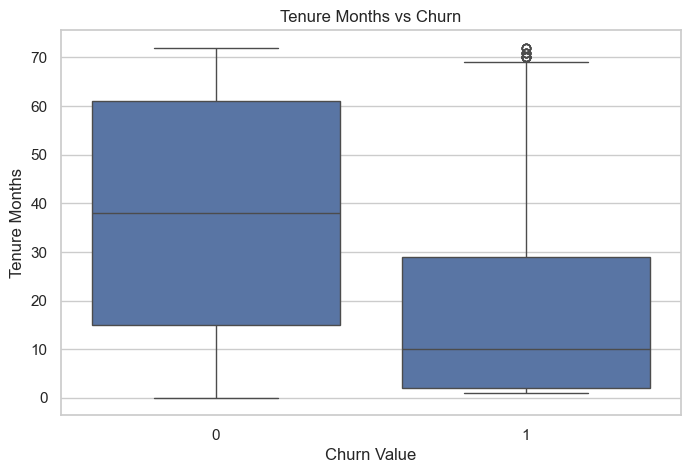

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=target, y="Tenure Months", data=df)
plt.title("Tenure Months vs Churn")
plt.show()


### 4.4 Monthly Charges vs Churn

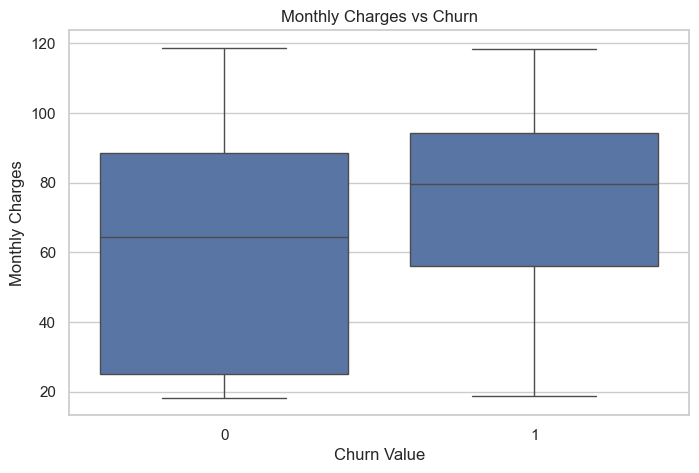

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=target, y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


### 4.5 Internet Service vs Churn

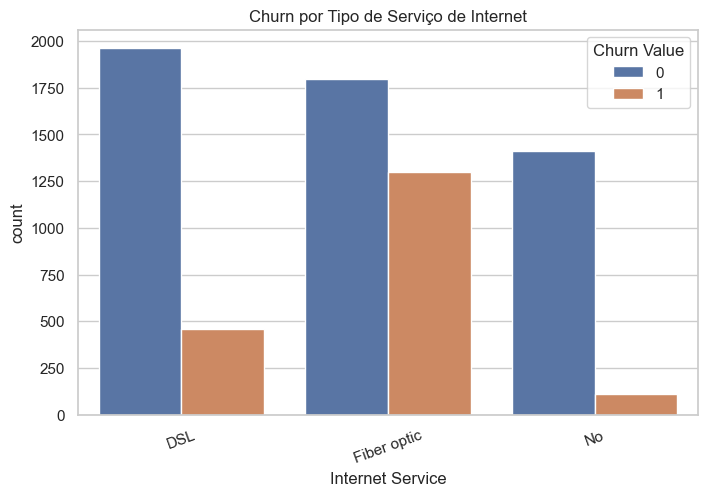

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Internet Service", hue=target)
plt.title("Churn por Tipo de Serviço de Internet")
plt.xticks(rotation=20)
plt.show()


### 4.6 Correlação entre variáveis numéricas

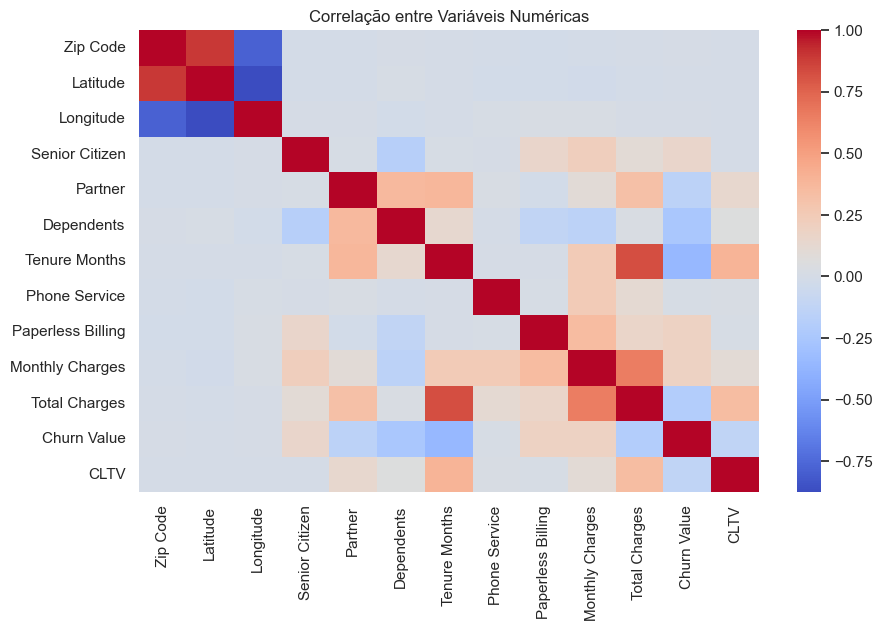

In [18]:
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlação entre Variáveis Numéricas")
plt.show()


## 5. Preparação para modelagem

In [19]:
X = df.drop(columns=[target]).copy()
y = df[target].copy()

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Blindagem para evitar erro de mistura de tipos no OneHotEncoder
X[cat_cols] = X[cat_cols].astype(str)

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


Numéricas: ['Zip Code', 'Latitude', 'Longitude', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'CLTV']
Categóricas: ['Country', 'State', 'City', 'Gender', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (5634, 26)
X_test: (1409, 26)
y_train: (5634,)
y_test: (1409,)


### 5.1 Pipeline de pré-processamento

In [21]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])


## 6. Baseline 1 - DummyClassifier

In [22]:
dummy_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent")),
])

dummy_pipeline.fit(X_train, y_train)
dummy_pred = dummy_pipeline.predict(X_test)

print(classification_report(y_test, dummy_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



In [23]:
dummy_metrics = {
    "accuracy": accuracy_score(y_test, dummy_pred),
    "precision": precision_score(y_test, dummy_pred, zero_division=0),
    "recall": recall_score(y_test, dummy_pred, zero_division=0),
    "f1": f1_score(y_test, dummy_pred, zero_division=0),
}

dummy_metrics


{'accuracy': 0.7345635202271115, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

## 7. Baseline 2 - Logistic Regression

In [24]:
log_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

log_pipeline.fit(X_train, y_train)

log_pred = log_pipeline.predict(X_test)
log_prob = log_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, log_pred, zero_division=0))
print("AUC-ROC:", roc_auc_score(y_test, log_prob))


              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409

AUC-ROC: 0.840153452685422


In [25]:
log_metrics = {
    "accuracy": accuracy_score(y_test, log_pred),
    "precision": precision_score(y_test, log_pred, zero_division=0),
    "recall": recall_score(y_test, log_pred, zero_division=0),
    "f1": f1_score(y_test, log_pred, zero_division=0),
    "auc_roc": roc_auc_score(y_test, log_prob),
}

log_metrics


{'accuracy': 0.7913413768630234,
 'precision': 0.6197604790419161,
 'recall': 0.553475935828877,
 'f1': 0.5847457627118644,
 'auc_roc': 0.840153452685422}

## 7.4 Baseline 3 - Random Forest

In [26]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, zero_division=0))
print("AUC-ROC:", roc_auc_score(y_test, rf_prob))


              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.68      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.8396484021803715


In [27]:
rf_metrics = {
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred, zero_division=0),
    "recall": recall_score(y_test, rf_pred, zero_division=0),
    "f1": f1_score(y_test, rf_pred, zero_division=0),
    "auc_roc": roc_auc_score(y_test, rf_prob),
}

rf_metrics


{'accuracy': 0.8019872249822569,
 'precision': 0.6779026217228464,
 'recall': 0.4839572192513369,
 'f1': 0.5647425897035881,
 'auc_roc': 0.8396484021803715}

### 7.1 Matriz de confusão da Regressão Logística

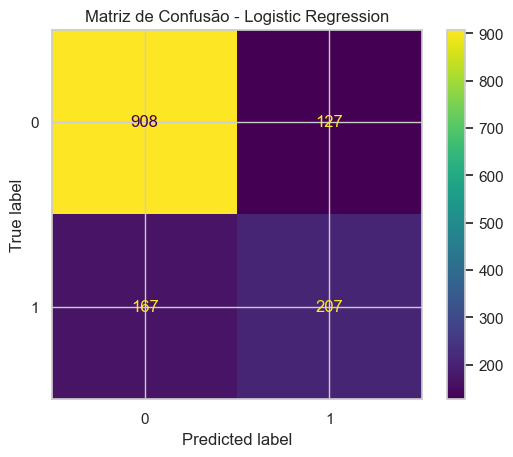

In [28]:
cm = confusion_matrix(y_test, log_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusão - Logistic Regression")
plt.show()


### 7.2 Curva ROC

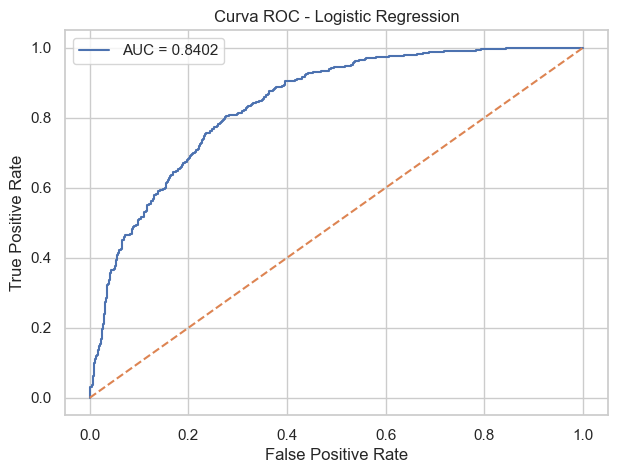

In [29]:
fpr, tpr, _ = roc_curve(y_test, log_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, log_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Logistic Regression")
plt.legend()
plt.show()


### 7.3 Ajuste de Threshold

In [31]:
threshold = 0.3  #Ajuste conforme necessário

log_pred_custom = (log_prob >= threshold).astype(int)

print(f"Threshold: {threshold}")
print(classification_report(y_test, log_pred_custom))

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



#### Análise Comparativa

In [32]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    preds = (log_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Recall:", recall_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("F1:", f1_score(y_test, preds))


Threshold: 0.2
Recall: 0.8422459893048129
Precision: 0.4779969650986343
F1: 0.6098741529525653

Threshold: 0.3
Recall: 0.7433155080213903
Precision: 0.5366795366795367
F1: 0.6233183856502242

Threshold: 0.4
Recall: 0.6497326203208557
Precision: 0.5664335664335665
F1: 0.6052303860523038

Threshold: 0.5
Recall: 0.553475935828877
Precision: 0.6197604790419161
F1: 0.5847457627118644

Threshold: 0.6
Recall: 0.45187165775401067
Precision: 0.7071129707112971
F1: 0.5513866231647635


#### Tabela de Comparação

In [33]:
results_threshold = []

for t in thresholds:
    preds = (log_prob >= t).astype(int)
    
    results_threshold.append({
        "threshold": t,
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    })

pd.DataFrame(results_threshold).sort_values(by="f1", ascending=False)

,threshold,precision,recall,f1
1,0.3,0.536680,0.743316,0.623318
0,0.2,0.477997,0.842246,0.609874
2,0.4,0.566434,0.649733,0.605230
3,0.5,0.619760,0.553476,0.584746
4,0.6,0.707113,0.451872,0.551387


## 8. Comparação dos baselines

In [34]:
results_df = pd.DataFrame([
    {"model": "DummyClassifier", **dummy_metrics},
    {"model": "LogisticRegression", **log_metrics},
    {"model": "RandomForest", **rf_metrics},
]).sort_values(by="f1", ascending=False)

results_df


,model,accuracy,precision,recall,f1,auc_roc
1,LogisticRegression,0.791341,0.619760,0.553476,0.584746,0.840153
2,RandomForest,0.801987,0.677903,0.483957,0.564743,0.839648
0,DummyClassifier,0.734564,0.000000,0.000000,0.000000,NaN


## 9. Tracking de experimentos com MLflow

Antes de rodar, inicie o UI do MLflow no terminal, se quiser visualizar os runs:

```bash
mlflow ui
```


In [53]:
mlflow.set_experiment("telco_churn_baselines")


2026/04/11 20:29:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/11 20:29:55 INFO mlflow.store.db.utils: Updating database tables
2026/04/11 20:29:58 INFO mlflow.tracking.fluent: Experiment with name 'telco_churn_baselines' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/BraianApM/Desktop/ML_Predict_Churn/notebooks/mlruns/1', creation_time=1775950198226, experiment_id='1', last_update_time=1775950198226, lifecycle_stage='active', name='telco_churn_baselines', tags={}, trace_location=None, workspace='default'>

In [54]:
with mlflow.start_run(run_name="dummy_classifier"):
    mlflow.log_param("model", "DummyClassifier")
    mlflow.log_param("strategy", "most_frequent")
    for metric_name, metric_value in dummy_metrics.items():
        mlflow.log_metric(metric_name, float(metric_value))


In [55]:
with mlflow.start_run(run_name="logistic_regression"):
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_state", 42)

    for metric_name, metric_value in log_metrics.items():
        mlflow.log_metric(metric_name, float(metric_value))

    mlflow.sklearn.log_model(log_pipeline, "model")


2026/04/11 20:30:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 20:30:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
with mlflow.start_run(run_name="random_forest"):
    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("min_samples_split", 2)
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("random_state", 42)

    for metric_name, metric_value in rf_metrics.items():
        mlflow.log_metric(metric_name, float(metric_value))

    mlflow.sklearn.log_model(rf_pipeline, "model")


## 10. Conclusões Finais

A análise exploratória dos dados revelou padrões importantes relacionados ao churn de clientes. Observou-se que clientes com contratos do tipo "month-to-month" apresentam maior probabilidade de cancelamento, enquanto clientes com maior tempo de permanência (tenure) tendem a permanecer na base.

Além disso, variáveis relacionadas a serviços contratados e valor mensal também demonstraram influência no comportamento de churn, indicando que o perfil de consumo do cliente é um fator relevante para a previsão.

Nos modelos baseline, o DummyClassifier evidenciou a limitação da métrica de acurácia em datasets desbalanceados, apresentando alta acurácia, porém incapaz de identificar corretamente clientes que cancelam.

A Regressão Logística apresentou desempenho significativamente superior, com AUC-ROC de aproximadamente 0.84 e melhor equilíbrio entre precision e recall, refletido no maior F1-score entre os modelos testados.

O modelo RandomForest, embora tenha apresentado maior precisão, mostrou desempenho inferior em recall, indicando menor capacidade de identificar clientes que efetivamente cancelam o serviço, o que é um ponto crítico no contexto de churn.

Foi realizada também a análise de ajuste de threshold, reduzindo o valor padrão de 0.5 para 0.3. Essa alteração resultou em aumento significativo do recall, permitindo capturar uma maior proporção de clientes com risco de churn, ao custo de um aumento moderado de falsos positivos. Essa decisão é justificada pelo maior impacto financeiro associado à perda de clientes em comparação ao custo de ações de retenção.

Dessa forma, o modelo escolhido para a próxima etapa foi a Regressão Logística com threshold ajustado, por apresentar o melhor equilíbrio entre desempenho técnico e aplicabilidade de negócio.

Como próximos passos, será realizada a implementação de uma rede neural do tipo MLP utilizando PyTorch, com o objetivo de avaliar se modelos mais complexos conseguem melhorar ainda mais a capacidade preditiva em relação aos baselines estabelecidos.